In [72]:
from dataclasses import dataclass
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np 
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torchfuzzy import FuzzyLayer, DefuzzyLinearLayer, FuzzyBellLayer, DefuzzyMaxLayer
import piqa
import sklearn.metrics as metrics
from sklearn.manifold import TSNE
from torchvision.transforms import v2
from torchinfo import summary
from matplotlib.colors import ListedColormap


In [73]:
batch_size = 256
learning_rate_ae = 1e-3
num_epochs_ae = 200
latent_dim = 16
kernels = 8
fuzzy_rules_count = 32
mnist_class_anomaly = 4
prefix = f"fuzzy_snn"
writer = SummaryWriter(f'runs/mnist/{prefix}_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

binary_cmap = ListedColormap(['yellow', 'red'], N=2)
device

device(type='cuda')

## Датасет  

In [74]:
def norm_and_transform(x):
    nimg = x.view(-1, 28, 28)
    nimg = torch.clamp(nimg, 0, 1)
    return nimg

def clamp(x):
    #nimg = 2.0*(x.view(-1, 28, 28) - 0.5)
    nimg = torch.clamp(x, 0, 1)
    return nimg

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Lambda(norm_and_transform)
])

augmentation = transforms.Compose([
    transforms.RandomRotation(15, fill=0), 
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), fill=0), 
    #transforms.RandomCrop(size=26),
    #transforms.Resize(size=(28, 28)),
    transforms.Lambda(clamp)
])

In [75]:
class DatasetWithRandomPairing(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self._dataset = dataset

    def __len__(self):
        return len(self._dataset)

    def __getitem__(self, idx):
        img_a, label_a = self._dataset[idx]
        expected = 0
        if np.random.random() < 0.5:
            expected = 1
        img_b, label_b = self._dataset[np.random.randint(0,len(self._dataset))]
        #while((expected == 0 and label_a == label_b) or (expected == 1 and label_a != label_b)):
        #    img_b, label_b = self._dataset[np.random.randint(0,len(self._dataset))]
        
        return (img_a, img_b, 0 if label_a == label_b else 1, label_a, label_b)
        

In [76]:
def get_target_and_mask(target_label):
    t = target_label
    return t 

train_data = DatasetWithRandomPairing(datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=True, 
    transform = transform,
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
))

idx = (train_data._dataset.targets != mnist_class_anomaly)
train_data._dataset.targets = train_data._dataset.targets[idx]
train_data._dataset.data = train_data._dataset.data[idx]
len(train_data)

54158

загружаем тестовую выборку

In [77]:
test_data = DatasetWithRandomPairing(datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=False, 
    transform=transform, 
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
))
len(test_data)

10000

Создаем итераторы датасетов

In [78]:

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=batch_size, 
    shuffle=True,
    
)
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False,
)

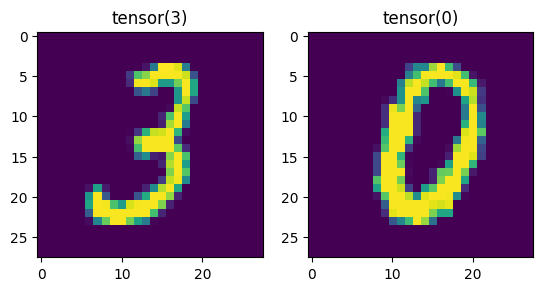

In [79]:
for img_a, img_b, lab, la, lb in iter(train_loader):
    R, C = 1, 2
    #plt.title(lab[0])
    plt.subplot(R, C, 1)
    plt.title(la[0])
    plt.imshow(img_a[0].squeeze())
    plt.subplot(R, C, 2)
    plt.title(lb[0])
    plt.imshow(img_b[0].squeeze())
    
    break

## Модель

In [80]:
class FSNN(nn.Module):

    def __init__(self, latent_dim, fuzzy_rules_count, kernels):
        super(FSNN, self).__init__()
                
        self.encoder = nn.Sequential(
            nn.Conv2d(1, kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(kernels, kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(2*kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(2*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(2*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(4*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(4*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(4*kernels, 8*kernels, kernel_size = 4, bias=False), 
            nn.BatchNorm2d(8*kernels, affine=False), 
            nn.Flatten(),
            nn.Linear(8*kernels, latent_dim, bias=False)
        )

        initial_centroids = np.random.random((fuzzy_rules_count, latent_dim))#np.zeros((fuzzy_rules_count, latent_dim))##0*
        initial_scales = np.ones((fuzzy_rules_count, latent_dim))
        self.fuzzy = FuzzyLayer.from_centers_and_scales(initial_centroids, initial_scales, trainable=True)

        
    def embedding(self, x):
        return self.encoder(x)
    
    def fuzzy_inference(self, dmu):
        return self.fuzzy(dmu)
    
    def forward(self, x):
        x = self.encoder(x)
        fz = self.fuzzy(x)
        return x, fz
    


#inp = torch.rand(10, 1, 28, 28)
#m = FSNN(latent_dim, fuzzy_rules_count, 16)
#summary(m, input_size=(batch_size, 1, 28, 28))


In [81]:
fvae = FSNN(latent_dim=latent_dim, fuzzy_rules_count=fuzzy_rules_count, kernels=kernels).to(device)

num_params = sum(p.numel() for p in fvae.parameters() if p.requires_grad)
print(f'Number of parameters: {num_params:,}')

summary(fvae, input_size=(batch_size, 1, 28, 28))

Number of parameters: 88,456


Layer (type:depth-idx)                   Output Shape              Param #
FSNN                                     [256, 16]                 --
├─Sequential: 1-1                        [256, 16]                 --
│    └─Conv2d: 2-1                       [256, 8, 24, 24]          200
│    └─Conv2d: 2-2                       [256, 8, 20, 20]          1,600
│    └─BatchNorm2d: 2-3                  [256, 8, 20, 20]          --
│    └─SiLU: 2-4                         [256, 8, 20, 20]          --
│    └─Conv2d: 2-5                       [256, 16, 16, 16]         3,200
│    └─Conv2d: 2-6                       [256, 16, 12, 12]         6,400
│    └─BatchNorm2d: 2-7                  [256, 16, 12, 12]         --
│    └─SiLU: 2-8                         [256, 16, 12, 12]         --
│    └─Conv2d: 2-9                       [256, 32, 8, 8]           12,800
│    └─Conv2d: 2-10                      [256, 32, 4, 4]           25,600
│    └─BatchNorm2d: 2-11                 [256, 32, 4, 4]           

## Losses

In [82]:
def criterion(x1, x2, label, margin: float = 1.0):
    """
    Computes Contrastive Loss
    the two samples are similar ((y = 0)) or dissimilar ((y = 1)).
    """

    dist = torch.nn.functional.pairwise_distance(x1, x2)

    loss = (1 - label) * torch.pow(dist, 2) \
        + (label) * torch.pow(torch.clamp(margin - dist, min=0.0), 2)
    loss = torch.mean(loss)

    return loss

In [83]:
def get_delta_loss(fz, labels):
    """
    the two samples are similar ((labels = 0)) or dissimilar ((labels = 1)).
    """
    return (fz.max(-1).values - 1 + labels).square().mean()

In [84]:
def get_loss(fz_a, fz_b, labels):
     """
    the two samples are similar ((labels = 0)) or dissimilar ((labels = 1)).
    """
     #acts = (fz_a * fz_b).sum(-1) #torch.cat((fz_a.unsqueeze(1), fz_b.unsqueeze(1)), dim=1).min(dim=1).values.squeeze(1).max(dim=1).values
     #reg = (1e-2 - fz_a.min(-1).values).clamp(min = 0) + (1e-2 - fz_b.min(-1).values).clamp(min = 0) 
     #sbj = (1 - fz_a.max(-1).values).square().sum() + (1 - fz_b.max(-1).values).square().sum()
     #norm = 0.5 * (1 - fz_a.sum(-1)).square().mean() + 0.5 * (1 - fz_b.sum(-1)).square().mean()
     #core = (1-fz_a[:,0]).square().mean() + (1-fz_b[:,0]).square().mean()
     obj = torch.minimum(fz_a, fz_b).max(-1).values#(fz_a*fz_b).max(-1).values#
     return torch.where(labels == 1, obj, 1 - obj).square().mean() #+ 1e-3 * norm #+ torch.where(labels == 0, 0, 1 - (fz_a*fz_b).sum()).square().sum()

#fz_a = torch.tensor([[1, 0], [0.8, 0.2], [0, 1]])
#fz_b = torch.tensor([[1, 0], [0.3, 0.7], [1, 0]])
#m = torch.tensor([[0.9]])
#labels = torch.tensor([1, 1, 0])


In [85]:
def centroid_loss(mu_a, mu_b, centroids, lambd = 1):
    sampled_x = torch.cat((mu_a, mu_b))
    distances = torch.cdist(sampled_x, centroids)
    neighs = torch.topk(distances, dim=-1, k=fuzzy_rules_count, largest=False).values
    weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
    return (weights*neighs).mean()

#centroids = fvae.fuzzy.get_centroids()
#mu_a = torch.rand(7, latent_dim).to(device)
#mu_b = torch.rand(7, latent_dim).to(device)

#sampled_x = torch.cat((mu_a, mu_b))
#distances = torch.cdist(sampled_x, centroids)
#neighs = torch.topk(distances, dim=-1, k=fuzzy_rules_count)
#lambd = 1
#weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
#weights*neighs.values
# (torch.exp(-neighs.indices)*neighs.values).mean()
#deltas = sampled_x.unsqueeze(1).repeat(1, fuzzy_rules_count, 1) - centroids[neighs]
#exponent_part = torch.exp(-neighs/lambd).unsqueeze(2).repeat(1, 1, latent_dim)
#exponent_part*deltas



In [86]:
def keep_eigenvals_positive_loss(layer, eps = 1e-10):
    ev = layer.get_transformation_matrix_eigenvals().real.min()
    ev = torch.clamp(ev, max=eps)
    return -ev

In [87]:
def get_match_rates(fz_a, fz_b):
    acts = (fz_a*fz_b).sum(-1)#torch.cat((fz_a.unsqueeze(1), fz_b.unsqueeze(1)), dim=1).min(dim=1).values.squeeze(1).max(dim=1).values
    return acts.cpu().numpy()

## Train AE

In [88]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
    
def train(model, dataloader, optimizer, optimizer_ct, sched, prev_updates, epoch, writer=None):
    model.train()  
    
    for batch_idx, (img_a, img_b, labels, _, _) in enumerate(tqdm(dataloader, disable=True)):
        
        aimg_a = img_a.to(device)#augmentation(img_a).to(device)
        aimg_b = img_b.to(device)#augmentation(img_b).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()  
        
        mu_a = model.embedding(aimg_a)  
        mu_b = model.embedding(aimg_b)  
        #centroids = model.fuzzy.get_centroids()
        fz_a = model.fuzzy_inference(mu_a)
        fz_b = model.fuzzy_inference(mu_b)

        loss = get_loss(fz_a, fz_b, labels)
        #loss = criterion(mu_a, mu_b, labels) + centroid_loss(mu_a, mu_b, centroids.detach(), 1)
        ev_loss = keep_eigenvals_positive_loss(model.fuzzy)
        if ev_loss.item() > 0:
            ev_loss.backward(retain_graph=True)
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1e-2)
        optimizer.step()  

        #centroid adjusting
        optimizer_ct.zero_grad()
        centroids = model.fuzzy.get_centroids()
        loss = centroid_loss(mu_a.detach(), mu_b.detach(), centroids, 1)
        loss.backward()
        optimizer_ct.step()
        
        if sched is not None:
            sched.step()
        
    if writer is not None:
        writer.add_scalar('FSNN/LR', get_lr(optimizer), global_step=epoch)
        writer.add_scalar('FSNN/LR', get_lr(optimizer_ct), global_step=epoch)
        
        
    return prev_updates + len(dataloader)

In [89]:
def test(model, dataloader, cur_step, epoch, writer=None):
    model.eval() 

    test_loss = 0.0
    embedings = []
    labels_expected = []
    predicted_match = []
    predicted_label = []
    match_true = []
    match_pred = []
    confm = np.zeros((10, fuzzy_rules_count))

    with torch.no_grad():
        for img_a, img_b, labels, la, lb in tqdm(test_loader, desc='Test MNIST', disable=True):
            aimg_a = img_a.to(device)
            aimg_b = img_b.to(device)
            labels = labels.to(device)
            
            mu_a = model.embedding(aimg_a)  
            mu_b = model.embedding(aimg_b)  

            #centroids = model.fuzzy.get_centroids()
            fz = model.fuzzy_inference(mu_a)
            test_loss = get_loss(fz_a, fz_b, labels) 

            #test_loss += get_loss(fz_a, fz_b, labels) #(fz_a*fz_b).sum(-1).square().mean().item()
            embedings.append(mu_a.cpu().numpy())
            fz_a_mx = fz.argmax(1)
            predicted_match.append(torch.where(fz.max(1).values > 0.1, fz_a_mx, -1).cpu().numpy())#
            predicted_label.append(la.cpu().numpy())#torch.where(fz_a.max(1).values>0.1, fz_a_mx, -1)
            labels_expected.append((la == mnist_class_anomaly).cpu().numpy())
            
            for i, j in zip(la.cpu().numpy(), fz_a_mx.cpu().numpy()):
                confm[i, j] += 1

            rates = torch.pairwise_distance(mu_a, mu_b).cpu().numpy()#fz.max(-1).values.cpu().numpy() #get_match_rates(fz_a, fz_b)
            for f, l in  zip(rates, labels):
                match_pred.append(f)        
                if l == 1:
                    match_true.append(1)
                else:
                    match_true.append(0)
            
    fpr, tpr, _ = metrics.roc_curve(match_true, match_pred)
    roc_auc = metrics.auc(fpr, tpr)

    embedings = np.concatenate(embedings, axis=0)
    predicted_label = np.concatenate(predicted_label, axis = 0)
    predicted_match = np.concatenate(predicted_match, axis = 0)
    labels_expected = np.concatenate(labels_expected, axis = 0)
    test_loss /= len(dataloader)
    
    print(f'[{cur_step}] Loss: {test_loss:.4f} AUC: {roc_auc:.4f}')
    
    if writer is not None:
        writer.add_scalar('FSNN/AUC', roc_auc, global_step=cur_step)
        writer.add_scalar('FSNN/Loss', test_loss, global_step=cur_step)
        
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        centroids = model.fuzzy.get_centroids().detach().cpu().numpy()
        ax[0].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_label, cmap='tab10', s=2)
        ax[0].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[1].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_match, cmap='tab10', s=2)
        ax[1].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[2].scatter(embedings[:, 0],      embedings[:,  1], c=labels_expected, cmap=binary_cmap, s=2)
        ax[2].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        
        writer.add_figure('FSNN/Emedding', fig, global_step=cur_step)

        fig, ax = plt.subplots(1, 1, figsize=(9, 9))
        ax.matshow(confm)
        writer.add_figure('FSNN/ConfMatrix', fig, global_step=cur_step)



In [90]:
prev_updates = 0
optimizer_ae = torch.optim.Adam(fvae.parameters(), lr=learning_rate_ae)
optimizer_ct = torch.optim.Adam(fvae.fuzzy.parameters(), lr=learning_rate_ae)
#sched = torch.optim.lr_scheduler.OneCycleLR(optimizer_ae, learning_rate_ae, epochs=num_epochs_ae, steps_per_epoch=len(train_loader))
sched = torch.optim.lr_scheduler.ConstantLR(optimizer_ae, learning_rate_ae)
sched_ct = torch.optim.lr_scheduler.StepLR(optimizer_ct, 10, 0.5)

In [ ]:
for epoch in range(num_epochs_ae):    
    prev_updates = train(fvae, train_loader, optimizer_ae, optimizer_ct, sched, prev_updates, epoch, writer=writer)
    test(fvae, test_loader, prev_updates, epoch, writer=writer)
    sched_ct.step()
    #scheduler.step()

## Визуализируем результаты

In [ ]:
fvae.eval()

FSNN(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (1): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (3): SiLU()
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (5): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (7): SiLU()
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (9): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (11): SiLU()
    (12): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_fea

In [ ]:
fvae.fuzzy.get_transformation_matrix()

tensor([[[ 0.9520, -0.1439, -0.0888,  ...,  0.2594,  0.5211, -1.3264],
         [-0.1439,  1.0514, -0.2810,  ...,  0.4335, -0.0686,  0.3743],
         [-0.0888, -0.2810,  0.4443,  ..., -0.0782, -0.1709,  0.2699],
         ...,
         [ 0.2594,  0.4335, -0.0782,  ...,  1.0934,  0.0322,  0.3312],
         [ 0.5211, -0.0686, -0.1709,  ...,  0.0322,  1.0422, -0.8500],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  1.0000]],

        [[ 1.2968,  0.3499,  0.1480,  ..., -0.1772,  0.2586, -1.4449],
         [ 0.3499,  1.1816, -0.0318,  ..., -0.1807,  0.2796, -1.5170],
         [ 0.1480, -0.0318,  0.5446,  ..., -0.1594,  0.0218, -0.8967],
         ...,
         [-0.1772, -0.1807, -0.1594,  ...,  1.2803,  0.0140,  0.0386],
         [ 0.2586,  0.2796,  0.0218,  ...,  0.0140,  1.1270, -1.2784],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  1.0000]],

        [[ 0.3720, -0.2767, -0.0271,  ...,  0.2159,  0.1204,  0.0919],
         [-0.2767,  0.9932,  0.5144,  ...,  0

In [ ]:
fvae.fuzzy.get_transformation_matrix_eigenvals().real

tensor([[3.5947e+00, 2.9449e+00, 1.4120e+00, 1.3025e+00, 1.1588e+00, 1.0644e+00,
         9.4087e-01, 8.8493e-01, 7.1519e-01, 5.4644e-01, 2.3906e-01, 1.2607e-01,
         7.1993e-02, 2.4109e-02, 7.6368e-03, 8.3241e-03],
        [2.6964e+00, 1.9858e+00, 2.9287e-02, 5.1894e-02, 2.6053e-01, 3.4271e-01,
         5.4333e-01, 1.1784e+00, 7.2324e-01, 1.0592e+00, 7.8256e-01, 1.0164e+00,
         8.8659e-01, 9.4042e-01, 9.2562e-01, 8.4504e-01],
        [3.1642e+00, 1.3536e+00, 1.2074e+00, 1.0715e+00, 1.0546e+00, 9.5620e-01,
         9.3324e-01, 6.7867e-01, 7.7306e-01, 3.3720e-01, 4.5703e-01, 6.1691e-02,
         3.9509e-02, 2.6678e-03, 1.4476e-02, 9.7365e-03],
        [4.0388e+00, 2.9653e+00, 2.2201e+00, 1.6675e+00, 4.9575e-01, 1.5743e+00,
         1.3916e+00, 7.2038e-01, 8.0056e-01, 1.1956e+00, 9.1722e-01, 9.3935e-01,
         9.7850e-01, 1.0929e+00, 1.0666e+00, 1.0231e+00],
        [3.0878e+00, 2.4798e+00, 1.5949e+00, 2.2197e-02, 2.1163e-01, 2.5630e-01,
         1.3433e+00, 3.4028e-01, 4.7332

In [ ]:
fvae.fuzzy.get_centroids()

tensor([[ 2.2718e-01, -2.5840e-01, -8.0698e-01, -6.8497e-01,  6.1607e-01,
          3.1367e-01,  3.4973e-01,  3.7437e-01, -1.0784e+00, -2.1712e-01,
          4.4853e-01,  5.0266e-02, -7.1597e-01,  3.9620e-01, -7.2699e-01,
         -1.1090e-01],
        [-7.2185e-01,  1.2987e+00,  3.4487e+00, -2.8553e+00,  2.9350e+00,
          4.0915e+00,  8.5480e+00,  4.0773e+00, -3.7703e+00, -1.1785e+00,
          3.2373e+00,  6.4371e+00, -7.8437e-01,  5.3042e+00,  4.9589e+00,
         -1.5452e+00],
        [-5.8209e-02,  1.6029e-01, -8.5161e-04, -2.2775e-01,  1.0536e+00,
         -6.5930e-02,  1.4649e+00,  4.1188e-01, -4.3709e-01, -4.3203e-01,
          5.6759e-01, -8.9184e-01, -8.5154e-01,  2.2199e-01, -5.5235e-02,
         -2.0664e-01],
        [ 2.9847e-01, -6.3687e-02, -3.2675e-01, -4.3287e-01,  3.5010e-01,
          3.9215e-01,  2.1059e-01,  5.1845e-01, -5.1728e-01, -3.7534e-02,
          3.7259e-01,  2.7823e-01, -4.9116e-01,  3.4845e-01, -4.6230e-01,
         -1.7930e-01],
        [ 1.0414e+00

In [ ]:
def get_arate_val(inp):
    _, fz = fvae.forward(inp)  
    return fz.max(-1).values.cpu().numpy()

MNIST HIST:   0%|          | 0/40 [00:00<?, ?it/s]

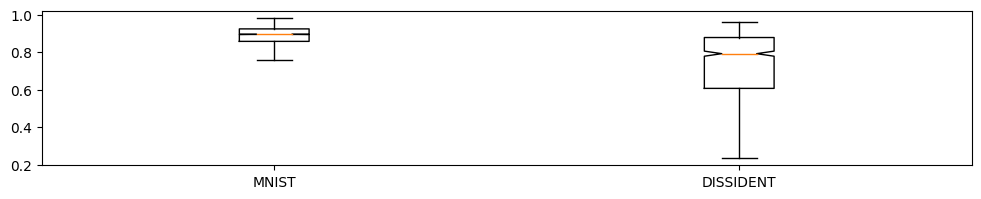

In [ ]:
firings_mnist = {}
firings_mnist['MNIST'] = []
firings_mnist['DISSIDENT'] = []

with torch.no_grad():
    for data, _, _, target, _  in tqdm(test_loader, desc='MNIST HIST'):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        for f, l in  zip(rates, target):
            if l != mnist_class_anomaly:
                firings_mnist['MNIST'].append(f)
            else:
                firings_mnist['DISSIDENT'].append(f)
        

labels, data = firings_mnist.keys(), firings_mnist.values()

fig = plt.figure(figsize =(12, 2))
plt.boxplot(data, notch=True, showfliers=False)
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()

writer.add_figure('Anomaly Detection', fig)

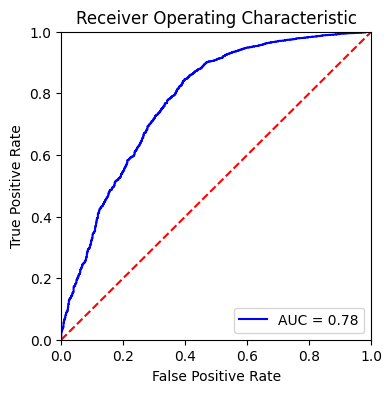

In [ ]:
with torch.no_grad():
    firing_levels = []
    lab_true = []
    lab_pred = []

    for data, _, _, lab, _  in tqdm(test_loader, desc='Test MNIST', disable=True):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        
        for f, l in  zip(rates, lab):
            firing_levels.append(f)
            lab_pred.append(f)        
            if l == mnist_class_anomaly:
                lab_true.append(0)
            else:
                lab_true.append(1)
                    
    fpr, tpr, threshold = metrics.roc_curve(lab_true, lab_pred)
    roc_auc = metrics.auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = threshold[optimal_idx]
    fig = plt.figure(figsize =(4, 4))
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    writer.add_figure('ROC', fig)

EMNIST VIS:   0%|          | 0/40 [00:00<?, ?it/s]

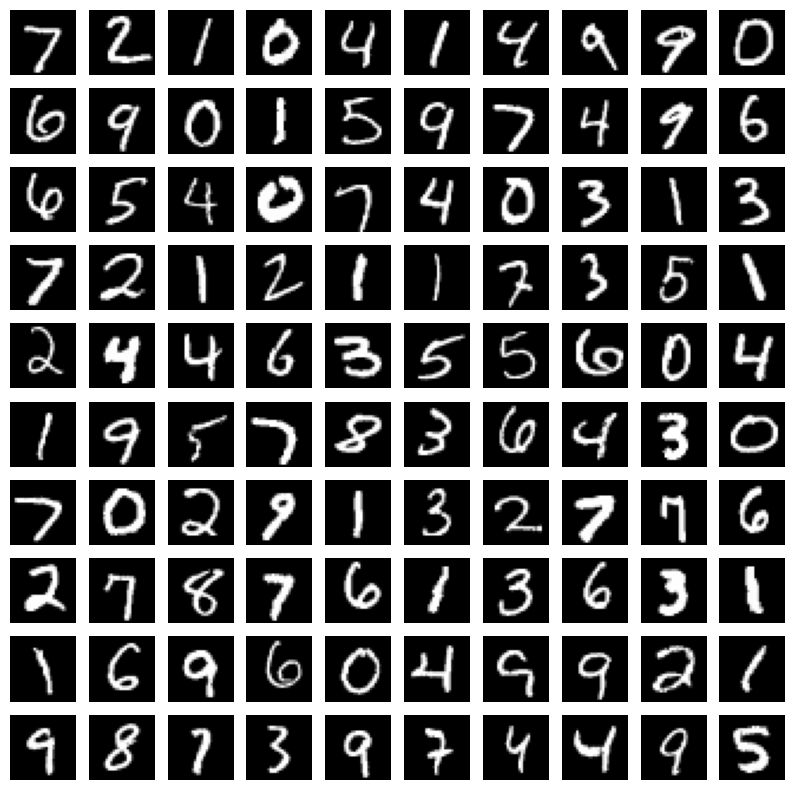

In [ ]:
threshold = optimal_threshold
n = 0
fig, ax = plt.subplots(10, 10, figsize=(10, 10))
with torch.no_grad():
    for data, _, _, labels, _  in tqdm(test_loader, desc='EMNIST VIS'):
        if n >= 100:
            break
        data = data.view((-1, 1, 28, 28)).to(device) 
        
        arate = get_arate_val(data)
        
        for i in range(data.shape[0]):
            if(arate[i] > threshold):
                img = data[i]
                ax[int(n / 10), int(n % 10)].imshow(img.view(28, 28).cpu().detach().numpy(), cmap='gray')
                ax[int(n / 10), int(n % 10)].axis('off')
                n = n + 1
                    
                if n >= 100:
                    break